In [6]:
import pandas as pd

In [7]:
# Load prices data
prices_day_minus_1_df = pd.read_csv('/content/prices_round_0_day_-1.csv', sep=';')
prices_day_minus_2_df = pd.read_csv('/content/prices_round_0_day_-2.csv', sep=';')

# Load trades data
trades_day_minus_1_df = pd.read_csv('/content/trades_round_0_day_-1.csv', sep=';')
trades_day_minus_2_df = pd.read_csv('/content/trades_round_0_day_-2.csv', sep=';')

print('Prices Round 0 Day -1:')
display(prices_day_minus_1_df.head())

print('\nPrices Round 0 Day -2:')
display(prices_day_minus_2_df.head())

print('\nTrades Round 0 Day -1:')
display(trades_day_minus_1_df.head())

print('\nTrades Round 0 Day -2:')
display(trades_day_minus_2_df.head())

Prices Round 0 Day -1:


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0



Prices Round 0 Day -2:


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0



Trades Round 0 Day -1:


,timestamp,buyer,seller,symbol,currency,price,quantity
0,3200,NaN,NaN,EMERALDS,XIRECS,9992.0,8
1,3400,NaN,NaN,TOMATOES,XIRECS,5009.0,2
2,5000,NaN,NaN,EMERALDS,XIRECS,9992.0,7
3,7000,NaN,NaN,TOMATOES,XIRECS,5010.0,4
4,9600,NaN,NaN,TOMATOES,XIRECS,4999.0,5



Trades Round 0 Day -2:


,timestamp,buyer,seller,symbol,currency,price,quantity
0,900,NaN,NaN,TOMATOES,XIRECS,5008.0,2
1,1700,NaN,NaN,TOMATOES,XIRECS,5006.0,3
2,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7
3,4100,NaN,NaN,TOMATOES,XIRECS,5002.0,3
4,5200,NaN,NaN,EMERALDS,XIRECS,9992.0,5


Please review the loaded dataframes above and let me know which two commodities (columns) you'd like to analyze and what type of plot you have in mind (e.g., time series, scatter plot, etc.).

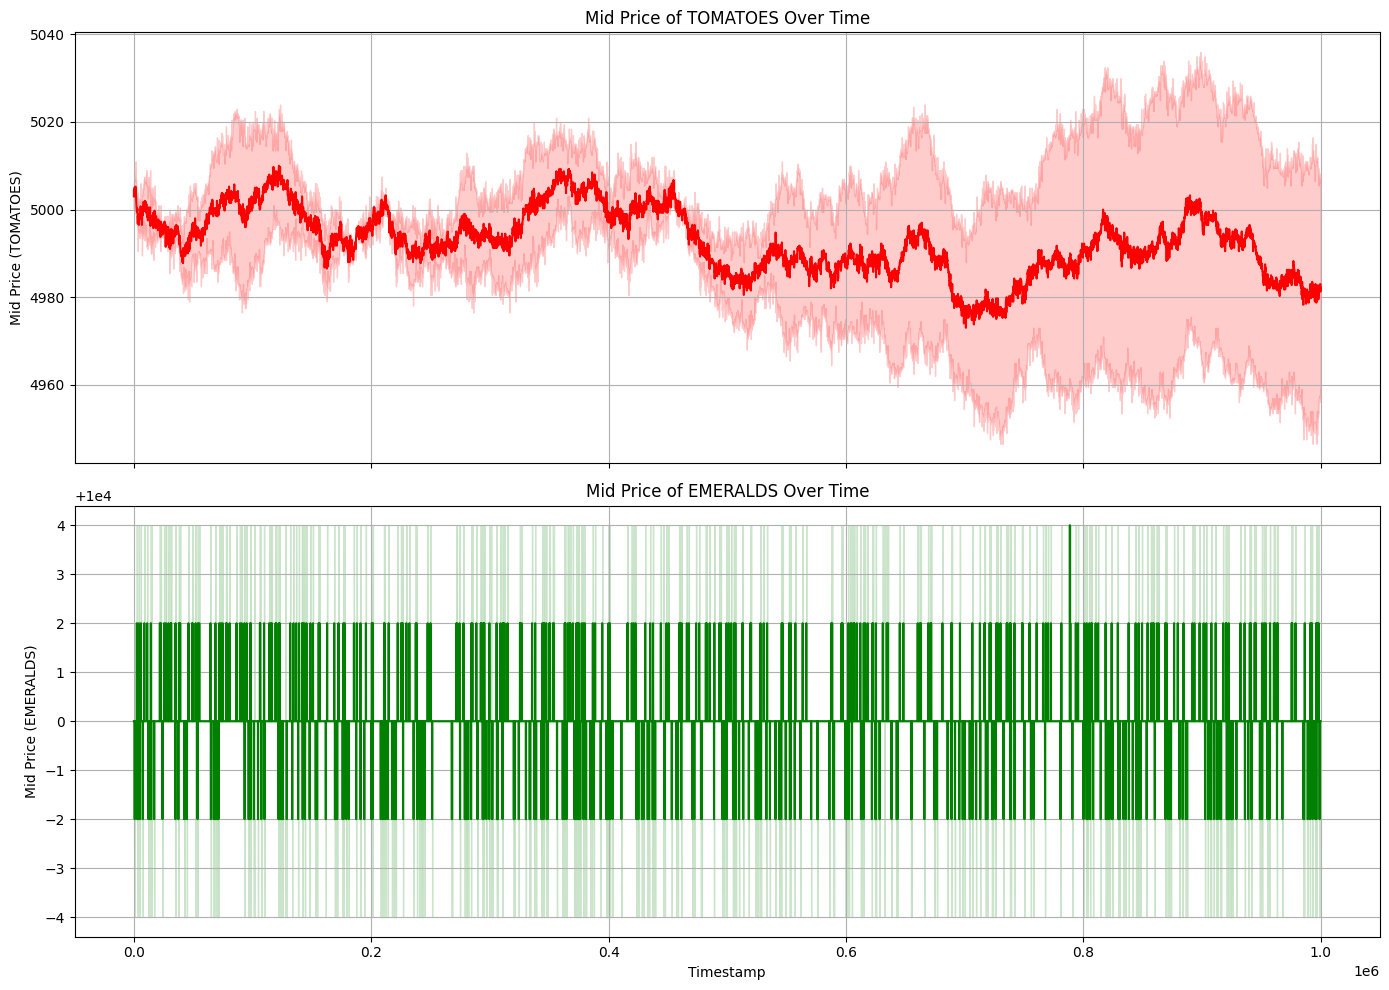

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine price data for day -1 and day -2
combined_prices_df = pd.concat([prices_day_minus_2_df, prices_day_minus_1_df])

# Filter for TOMATOES and EMERALDS
tomatoes_emeralds_prices = combined_prices_df[combined_prices_df['product'].isin(['TOMATOES', 'EMERALDS'])].copy()

# Convert timestamp to a numerical type if it's not already, for plotting on x-axis
# In this dataset, timestamp seems to be an integer representing time steps.
tomatoes_emeralds_prices['timestamp'] = pd.to_numeric(tomatoes_emeralds_prices['timestamp'])

# Create a figure with two subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

# Plot for TOMATOES
sns.lineplot(data=tomatoes_emeralds_prices[tomatoes_emeralds_prices['product'] == 'TOMATOES'],
             x='timestamp', y='mid_price', ax=axes[0], color='red')
axes[0].set_title('Mid Price of TOMATOES Over Time')
axes[0].set_ylabel('Mid Price (TOMATOES)')
axes[0].grid(True)

# Plot for EMERALDS
sns.lineplot(data=tomatoes_emeralds_prices[tomatoes_emeralds_prices['product'] == 'EMERALDS'],
             x='timestamp', y='mid_price', ax=axes[1], color='green')
axes[1].set_title('Mid Price of EMERALDS Over Time')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Mid Price (EMERALDS)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

This plot shows the `mid_price` of 'TOMATOES' and 'EMERALDS' over the recorded timestamps for both days. If you meant a different interpretation of 'positions', please let me know!

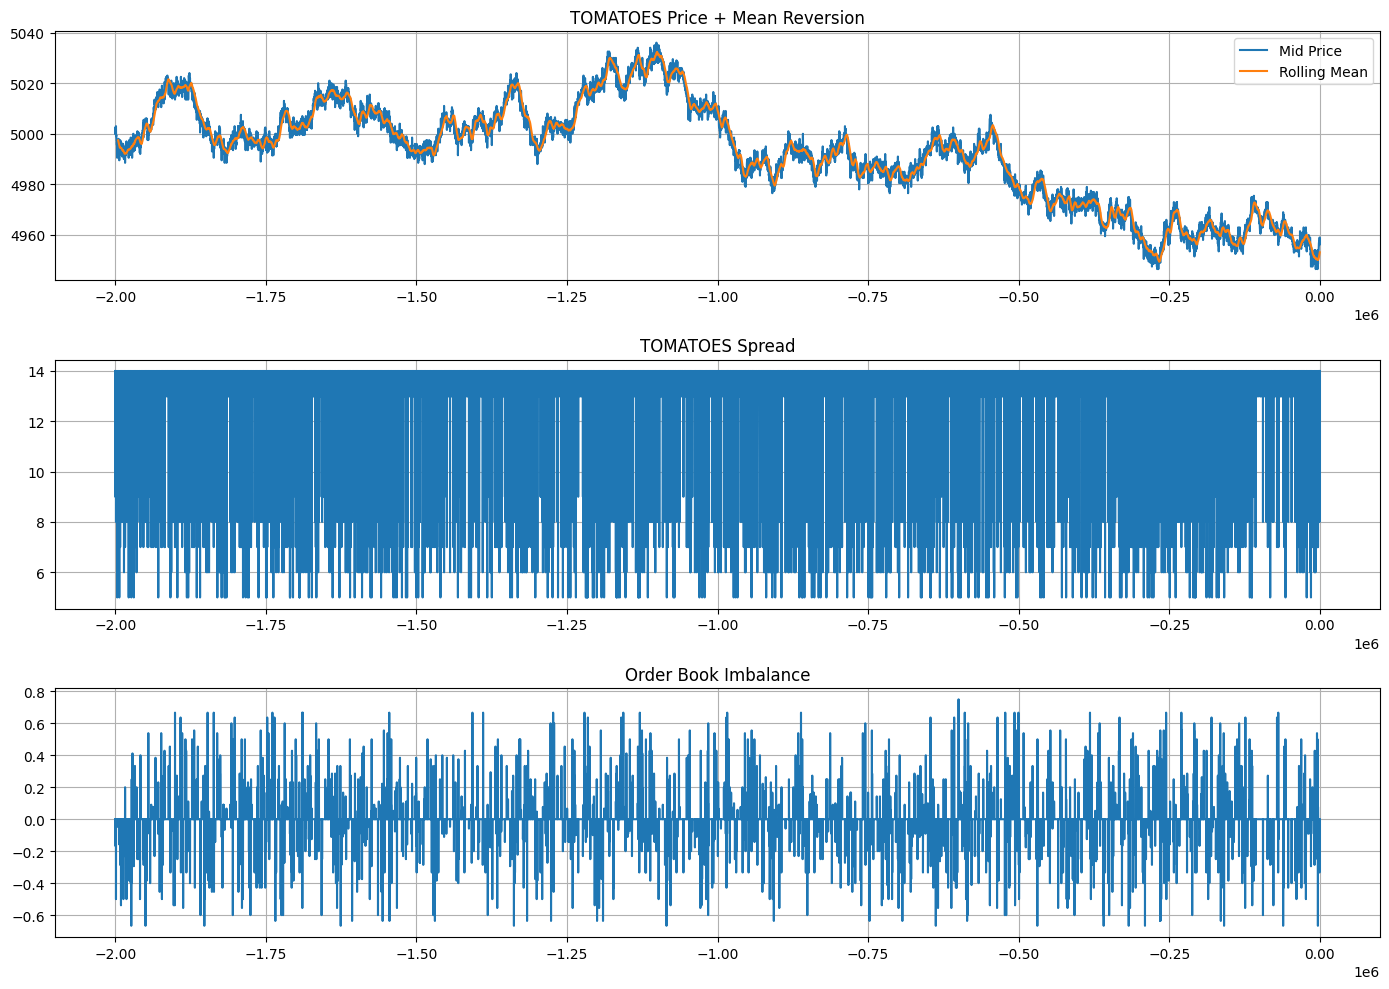


=== ORDER FLOW ===
product
EMERALDS     -93
TOMATOES    2503
Name: signed_volume, dtype: int64

=== SIMPLE STRATEGY PnL ===
3773.0

=== EMERALDS STATS ===
         mid_price        spread
count  20000.00000  20000.000000
mean    9999.99760     15.738400
std        0.72334      1.422838
min     9996.00000      8.000000
25%    10000.00000     16.000000
50%    10000.00000     16.000000
75%    10000.00000     16.000000
max    10004.00000     16.000000


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. LOAD DATA
# =========================
prices_d1 = pd.read_csv('prices_round_0_day_-1.csv', sep=';')
prices_d2 = pd.read_csv('prices_round_0_day_-2.csv', sep=';')

trades_d1 = pd.read_csv('trades_round_0_day_-1.csv', sep=';')
trades_d2 = pd.read_csv('trades_round_0_day_-2.csv', sep=';')

# Combine
prices = pd.concat([prices_d2, prices_d1], ignore_index=True)
trades = pd.concat([trades_d2, trades_d1], ignore_index=True)

# =========================
# 2. BASIC CLEANING
# =========================
prices = prices.dropna(subset=['bid_price_1', 'ask_price_1'])

# Create continuous time
prices['global_time'] = prices['day'] * 1_000_000 + prices['timestamp']
trades['global_time'] = trades['timestamp']  # trades don't have day

# =========================
# 3. FEATURE ENGINEERING
# =========================

# Mid price
prices['mid_price'] = (prices['bid_price_1'] + prices['ask_price_1']) / 2

# Spread
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']

# Order book imbalance (use level 1 only)
prices['bid_vol'] = prices['bid_volume_1'].fillna(0)
prices['ask_vol'] = prices['ask_volume_1'].fillna(0)

prices['imbalance'] = (
    (prices['bid_vol'] - prices['ask_vol']) /
    (prices['bid_vol'] + prices['ask_vol'] + 1e-6)
)

# =========================
# 4. TRADE SIDE INFERENCE
# =========================
# Merge nearest price snapshot
prices_small = prices[['global_time', 'product', 'bid_price_1', 'ask_price_1']]

trades = trades.sort_values('timestamp')
prices_small = prices_small.sort_values('global_time')

# Rename 'symbol' to 'product' in trades to match prices_small for merging
trades = trades.rename(columns={'symbol': 'product'})

# Approximate join (asof)
trades = pd.merge_asof(
    trades,
    prices_small,
    left_on='timestamp',
    right_on='global_time',
    by='product',
    direction='nearest'
)

# Classify trade direction
def classify_trade(row):
    if abs(row['price'] - row['ask_price_1']) < abs(row['price'] - row['bid_price_1']):
        return 1   # buyer initiated
    else:
        return -1  # seller initiated

trades['trade_sign'] = trades.apply(classify_trade, axis=1)

# Order flow = signed volume
trades['signed_volume'] = trades['trade_sign'] * trades['quantity']

# =========================
# 5. SPLIT PRODUCTS
# =========================
tom = prices[prices['product'] == 'TOMATOES'].copy()
eme = prices[prices['product'] == 'EMERALDS'].copy()

# =========================
# 6. SIGNALS (THIS IS KEY)
# =========================

# Rolling mean for mean reversion
window = 50

tom['rolling_mean'] = tom['mid_price'].rolling(window).mean()
tom['z_score'] = (tom['mid_price'] - tom['rolling_mean']) / tom['mid_price'].rolling(window).std()

# Trading signal
# +1 = buy, -1 = sell
tom['signal'] = 0
tom.loc[tom['z_score'] < -1, 'signal'] = 1
tom.loc[tom['z_score'] > 1, 'signal'] = -1

# =========================
# 7. PLOTS
# =========================

plt.figure(figsize=(14, 10))

# --- TOMATOES MID PRICE ---
plt.subplot(3, 1, 1)
plt.plot(tom['global_time'], tom['mid_price'], label='Mid Price')
plt.plot(tom['global_time'], tom['rolling_mean'], label='Rolling Mean')
plt.title('TOMATOES Price + Mean Reversion')
plt.legend()
plt.grid()

# --- SPREAD ---
plt.subplot(3, 1, 2)
plt.plot(tom['global_time'], tom['spread'])
plt.title('TOMATOES Spread')
plt.grid()

# --- IMBALANCE ---
plt.subplot(3, 1, 3)
plt.plot(tom['global_time'], tom['imbalance'])
plt.title('Order Book Imbalance')
plt.grid()

plt.tight_layout()
plt.show()

# =========================
# 8. TRADE FLOW ANALYSIS
# =========================

flow = trades.groupby(['product'])['signed_volume'].sum()
print("\n=== ORDER FLOW ===")
print(flow)

# =========================
# 9. BASIC BACKTEST (VERY SIMPLE)
# =========================

position = 0
pnl = 0

for i in range(len(tom) - 1):
    signal = tom.iloc[i]['signal']
    price = tom.iloc[i]['mid_price']
    next_price = tom.iloc[i+1]['mid_price']

    if signal == 1:   # buy
        pnl += (next_price - price)
    elif signal == -1:  # sell
        pnl += (price - next_price)

print("\n=== SIMPLE STRATEGY PnL ===")
print(pnl)

# =========================
# 10. EMERALDS CHECK
# =========================
print("\n=== EMERALDS STATS ===")
print(eme[['mid_price', 'spread']].describe())